In [ ]:
VERY IMPORTANT REGARDING INTERVIEW

In [ ]:
There are two problems with imbalanced data:
1. The model becomes biased towards majority class
2. Some metrics are not reliable. For example in case of classification we mostly focus on
accuracy but if we have imbalanced data, such as we have 900 cases from the dataset that belong
to class one and only 100 cases from the dataset belong to class two, then it will predict
class one bestly. When we give him any data point for prediction, it will always or mostly always
predict it as Class 1, which means that the Class 1 accuracy is good but it is highly bad for 
predicting the cases from Class 2, although accuracy is 90%. yani class 2 ko predict krny k liye 
y bhhhtt bura result de ga, 
-> yani jab bhi koi data point den gy predcit krny k liye, y hamesha class 1 hi predict kry ga, 
yani 900 data points accuractely predict huy or just 100 wrong predict huy, is liye accuracy to 
90% a gi lekin class 2 predict krny k liye bhhtt ghalat respond kry ga
that's why imbalances in the data set should highly be addressed.

Matrices are not just limited to accuracy. Other metrics such as Recall, Precision, etc.,
also become unreliable. 

In [ ]:
There are certain fields in which there is a lot of class imbalance and 
we have to focus on the minority class, and in following domains ML is still implemented
    1---  finance, in which fraud detection and credit risk assessment are very 
important, where machine learning is implemented. In both cases minority class detection
is very important because there is a very few number of transactions that are fraudulent.
    2---  Medical: in which we will detect rare diseases, there is a lot of class imbalance because
there are a lot of patients who do not have a rare disorder and only some have a rare disorder. 
Our main focus is to determine the disorder that is rare. So of course this class is present
in a very small amount; this is a minority class. 
    3---  Manufacturing: manufacturing (early determination of problems in machine)
    4---  Environmental sciences (predicting earthquacks etc)

In [ ]:
1-- UNDERSAMPLING:  can cause underfitting due to information loss
2-- OVERSAMPLING:   can cause overfitting due to data duplication, also increase data which is a 
                    a disadvantage too, because if we already have data in a million number of rows,
                    then oversampling will increase a lot of rows, which is a disadvantage because
                    it will make our model too slow to train. 

# SMOTE

In [ ]:
3--  SMOTE (synthetic minority oversampling technique)
This is very popular, it is actually an oversampling technique but there is a major difference
from random oversampling. Instead of just duplicating the minority class data points, it says that
we have to create some new data points. 
    or y esy krta h k 2 minority class data points k beech m new data point generate krta h, like 
shown in following image, right side vali image m blue data points are minority data points 
and red points are the new generated data points via SMOTE, 

THE NEW DATA POINTS (SYNTHETIC DATA POINTS) GENERATED USING INTERPOLATION TECHNIQUE

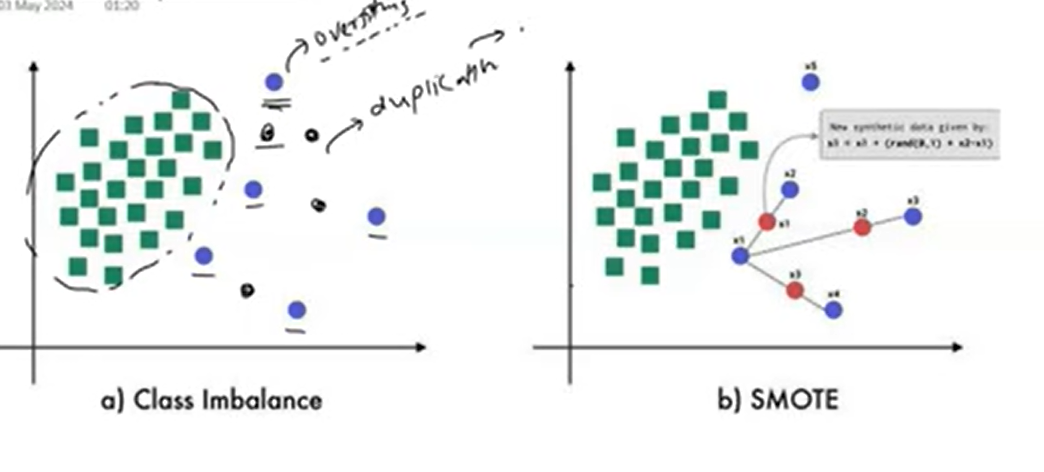

In [2]:
from IPython.display import Image
Image('smote.png', width=500, height=500)

In [ ]:
1- the first step is that: 
we apply KNN, means we determine 5 nearest neighbors of each minority class data point
2-  then we randomly choose a minority class data point. 
3-  select a random neighbor from that selected minority class data point for interpolation. 
4-  now we will create a synthetic data point between that selected minority class data 
point and its selected random neighbors, and the formula to create that synthetic point is
    opriginal sample - factor * (original sample - neighbor)
 factor in this formula is actually a random number between 0 and 1. 
    


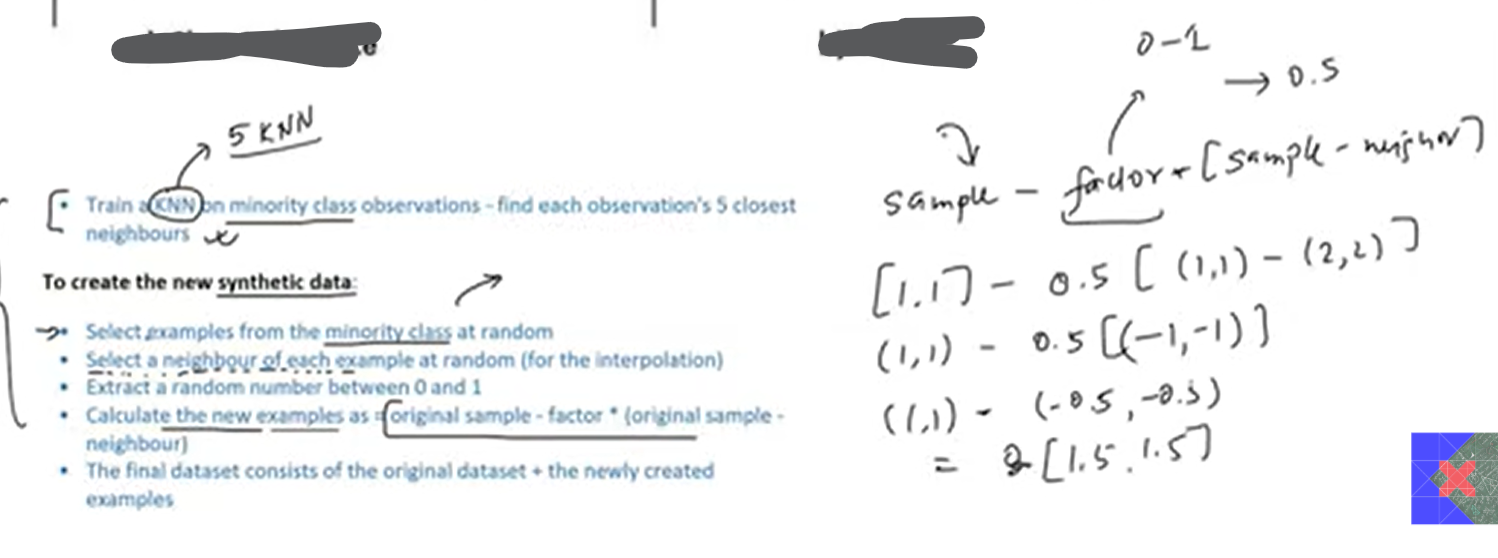

In [5]:
Image('synthetic point generation process.png', width=500, height=500)

In [ ]:
In the above example our minority class sample is present at data point (1,1) and the random 
sample neighbor of that data point is (2,2). After calculation we get (1.5,1.5), meaning
the new data point is plotted where the x-axis is 1.5 and the y-axis is 1.5. 

In [ ]:
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Create a dummy imbalanced dataset (90% majority, 10% minority)
X, y = make_classification(
    n_samples=5000, 
    n_features=10, 
    weights=[0.90, 0.10], 
    random_state=42
)
print(f"Original class distribution: {Counter(y)}")

# 2. Split data into train and test sets FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Maintains class proportions in splits
)

# 3. Initialize SMOTE
# By default, it balances the classes to a 50/50 ratio
smote = SMOTE(random_state=42) # default is k = 5

# 4. Fit SMOTE only to the TRAINING data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 5. Verify the new balanced distribution
print(f"Resampled training distribution: {Counter(y_train_resampled)}")
print(f"Untouched test distribution: {Counter(y_test)}")


In [ ]:
When we are applying SMOTE to handle class imbalance, in the first step we randomly select a
minority class data point and then randomly select the neighbor of that data point, and we 
generate a synthetic data point between the two. What will happen in the next cycle? It is possible
that it will select the same selected minority class data point or it will select a 
different minority data point. 


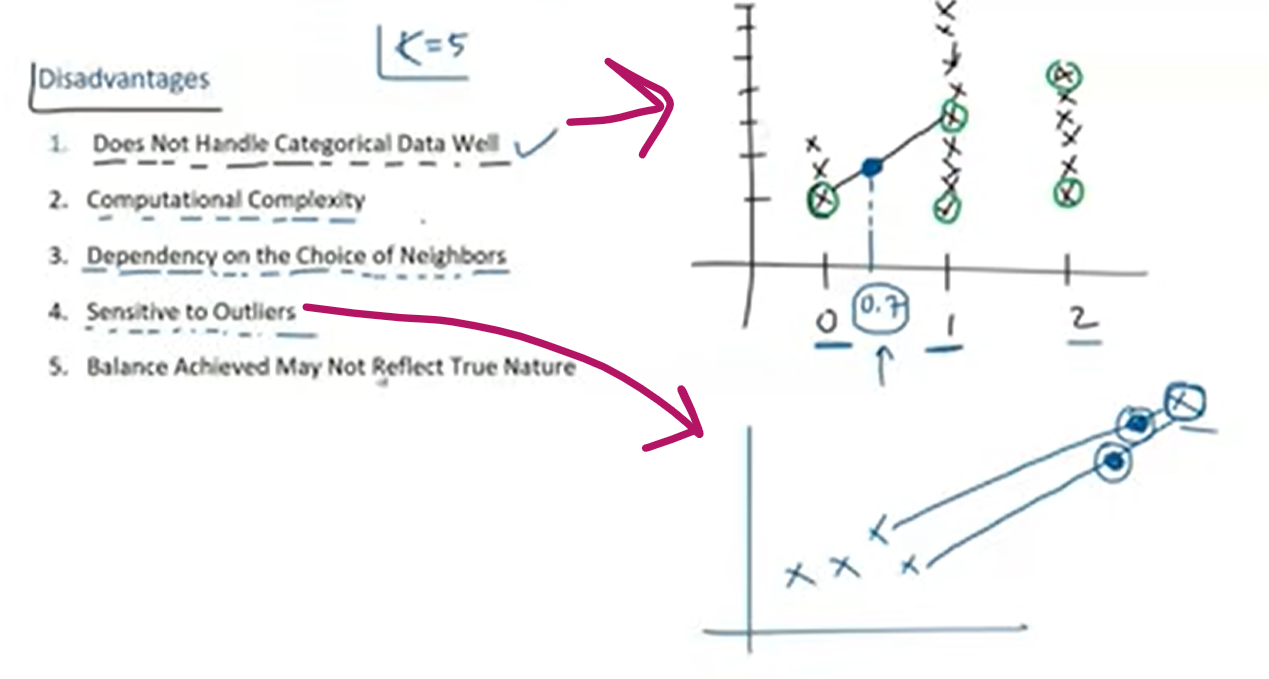

In [6]:
Image('drawbacks.png', width=500, height=500)

In [ ]:
It has a lot of drawbacks but one is categorical data. Consider the top arrow in which 
we have shown the visualization of that disadvantage. Suppose we have three classes
on the x-axis: 0, 1, and 2. The data points around the green circle are actually minority
class data points. When we determine the nearest neighbors of those minority class data points,
suppose we get some data points from class label 1. When we determine the synthetic data
point between those two neighbors, after calculating the formula we will somehow
get a value when the x-axis is 0.7. Of course it is not possible because we have only 
three classes: 0, 1, and 2, so it is not applicable to handle categorical data. 

It is computationally expensive because when we have a lot of data, the nearest neighbors
are computationally expensive. 

We also depend on determining the value of k. Sometimes we calculate the value of k as 5, 
sometimes we calculate it as 3. Although the default value is 5, it depends on the data. 
But if we put k = 1, then there will be only one data point. If in the next run vhi 
data point is selected again, then a lot of synthetic neighbors will be generated between
that data point and it's only one neighbor. 

It is highly sensitive to outliers because consider the bottom arrow from the image. 
The outliers are also present in minority classes and in random sampling it is possible
that sometimes the outlier will be selected. When we will determine the nearest neighbor
of that outlier, then the new synthetic data point is generated between
the minority class outlier and the original data minority class. It will generate 
a lot of new synthetic data points that are actually outliers. 

Last is that the newly generated synthetic data points do not show the visualization or
representation of our original data. They might be just dummy data points and will not provide
actual information. 


That's why use SMOTE wisely. 

# balanced random forest

In [ ]:

In Random Forest we simply create some samples and then train a decision tree on each sample. 
We will calculate the final result as if:
1. the first model says that it should be 0
2. the second says that 1
3. the third says that 0
then the final result would be 0, this is simple ensembvle learning technique

  We will change random forest into balanced random forest, in which we will
make balanced samples. In the first sample we will randomly select 300 data points 
from the majority class and 300 from the minority class. The same is the case
with the other two samples. problem solved!

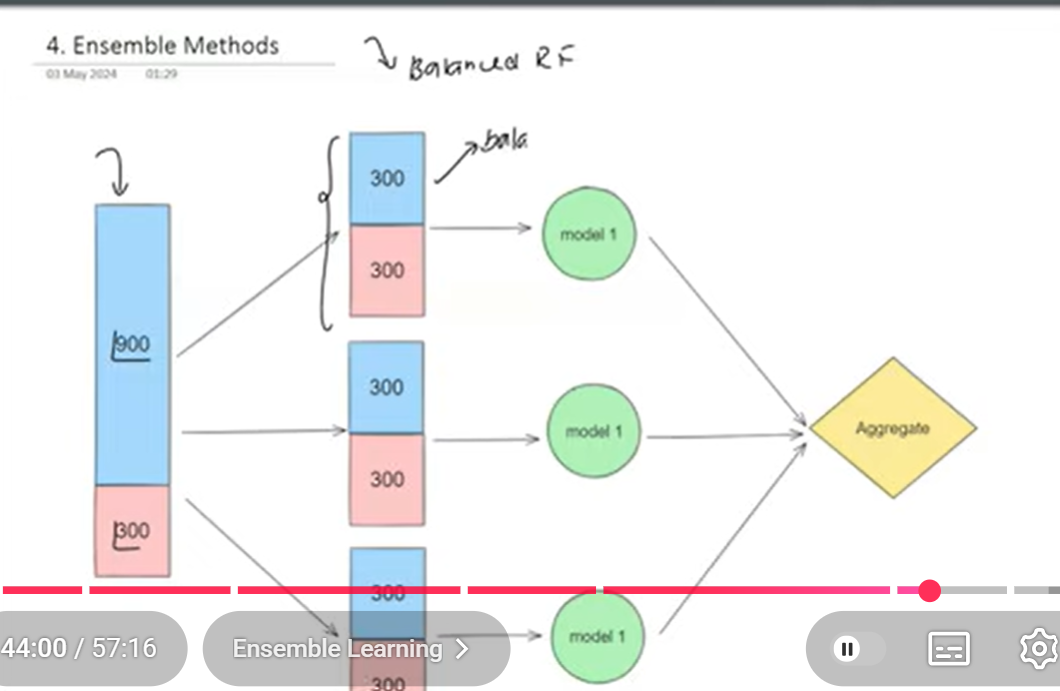

In [9]:
Image('balanced random forest.png', width=500, height=500)

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
 then simply, so split the data for testing and training, then fit the data to that model
to X_train and y_train and then we will get the results. Just simply instead of loading a random
forest classifier, load a balanced random forest classifier to handle imbalanced 
data automatically within the model. 

# Other techniques

In [ ]:
We will change the learning process of some models. For example, we will change the class weights
parameter when we are loading the model. Almost all the models, including logistic regression
and decision trees, etc., have this feature of class weights. 
  The following model loading shows that when we have class 1 then the weight should be 1
and for the class 0 the weight should be 5. This means that when the model is making mistakes
in predicting class 0 it should take the mistakes more seriously because we are adding the
weights five times more to that class. 

In [14]:
from sklearn.linear_model import LogisticRegression
LogisticRegression(class_weight={1:1, 0:5})

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 5, 1: 1}"
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
We can also use class weight is equal to balance here and the model will punish the
minority class mistakes more heavily.
    It will just use the formula as 

weight of class = total samples / (number of classes * samples in class )
for class 1 : 1000/2*900 = 0.56
for class 2 : 1000/2*100 = 5

class 2 weights will be 5, means making mistakes in predicting class 2 will be punished 9 times
heavily